# Sprint 4 - Clustering

### Descripción
El equipo de Marketing de la compañía utiliza regularmente campañas de mailing para interactuar con sus clientes potenciales. Se le consulta al equipo de Data Science si puede identificar segmentos de clientes de acuerdo a su interacción con la publicidad via correo electrónico. ¿Existen grupos según su comportamiento? ¿Se presenta algún patrón útil?


La idea es que puedan interpretar y analizar los datos, detectar algun patron, crear nuevos atributos y entrenar un modelo que permita segmentar a los usuarios.

Es necesario analizar los clusters finales y poder caracterizarlos, pudiendo identificar cualidades particulares de cada uno.

El análisis no tiene limites, podés extenderte lo que consideres.







| Columna      | Descripción breve                                                           | Aclaración / Interpretación adicional                                                                 |
|--------------|------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------|
| Id           | Identificador único de cada usuario.                                        | No se repite entre filas. Cada registro corresponde a un usuario distinto.                            |
| send         | Número total de correos enviados al usuario.                                | Incluye todos los envíos, sin importar si fueron abiertos o no.                                       |
| bounce       | Número de correos rebotados (no entregados).                                | Recuento de correos que no llegaron por fallos como email inválido o bandeja llena.                   |
| open         | Número de veces que el usuario abrió correos.                               | Un usuario puede abrir un mismo correo varias veces. No implica clics.                                |
| click        | Número de veces que el usuario hizo clic en enlaces dentro de correos.      | Cuenta clics en cualquier enlace. Puede haber múltiples clics por correo o clics sin haber abierto.   |
| total        | Suma de send, bounce, open y click para ese usuario.                        | Puede no coincidir perfectamente en algunos registros; verificar consistencia antes de usar.           |
| comprador    | 1 si el usuario realizó al menos una compra, 0 si no compró nunca.          | Variable binaria. Puede usarse como objetivo en modelos de predicción (target).                       |
| hour         | Hora promedio del día en que el usuario interactuó -ya sea aperturas o clicks dentro de los mismos- con los correos.         | Valor entre 0 y 23, con decimales. Representa el promedio ponderado de las horas de interacción.      |
| day_of_week  | Día promedio de la semana de interacción -ya sea aperturas o clicks dentro de los mismos-.          | Valor continuo entre 0 y 6 -> 0 = lunes, 6 = domingo. Indica el día medio de actividad; por ejemplo, 2.5 ≈ martes/miércoles.    |

### Criterios de evaluación:

1. Notebooks ordenados y facil de comprender
Utilicen las estructuras markdowns con diferentes números de '#', para crear los títulos y subtítulos de cada apartado.

2. Exploración y preparación de los datos
Realicen una exploración inicial del conjunto de datos con el fin de comprender sus variables, detectar valores atípicos o faltantes, y preparar la información para su uso en modelos de clustering. Analicen el potencial valor que una segmentación podría aportar en un contexto de negocio real (por ejemplo, campañas de marketing, personalización de ofertas, etc.).

3. Selección del número óptimo de clusters
Justifiquen de manera clara el criterio utilizado para determinar la cantidad adecuada de clusters (por ejemplo, codo de la curva de inercia, silueta, etc.). Utilicen esta segmentación para crear al menos una nueva variable en el conjunto de datos (por ejemplo, una columna que indique el cluster asignado a cada observación).

4. Análisis y caracterización de los clusters
Describan y comparen los clusters obtenidos utilizando variables relevantes. Caractericen brevemente a cada grupo identificando patrones, similitudes o diferencias relevantes.

5. Recomendaciones para el equipo de marketing (OPCIONAL para quien quiera practicar sobre este topico)
Elaboren recomendaciones básicas y accionables, orientadas a un equipo de marketing. No se espera que conozcan de esa área, pero será interesante que traduzcan resultados técnicos en conclusiones de negocio comprensibles y lógicas. Las recomendaciones deben estar alineadas con los objetivos hipotéticos de análisis que cada equipo defina.

### Lectura de datos

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
id = '1is8rJK3QcxP9LIdyaQLZiNWb8sYFOHiU'
url=f'https://drive.google.com/uc?id={id}'
df = pd.read_excel(url)

In [ ]:
df.sample(10)

,Id,send,bounce,open,click,Total,Comprador,hour,day_of_week
39548,903811,10,0,0,0,10,0,20.500000,1.400000
173610,875859,4,0,0,0,4,1,21.750000,1.500000
180131,825136,3,0,0,0,3,1,20.333333,2.333333
5669,2105851,2,0,0,0,2,1,17.500000,5.000000
184808,825252,7,0,0,0,7,1,20.428571,1.857143
25253,1522092,8,0,0,0,8,0,18.625000,2.125000
177845,267664,1,1,0,0,2,1,16.000000,0.000000
60709,165597,2,0,0,0,2,1,18.500000,1.500000
116256,891383,1,0,0,0,1,0,21.000000,0.000000
75165,1211642,2,0,0,0,2,1,18.500000,1.500000


### EDA

In [ ]:
df.columns

Index(['Id', 'send', 'bounce', 'open', 'click', 'Total', 'Comprador', 'hour',
       'day_of_week'],
      dtype='object')

In [ ]:
df.drop(columns=['Total'], inplace=True)

In [ ]:
df_sampled = df.groupby('Comprador').sample(frac=0.30, random_state=42)
df_sampled = df_sampled[['Id', 'send', 'bounce', 'open', 'click', 'Comprador', 'hour','day_of_week']]

In [ ]:
X = df_sampled.drop(columns='Comprador').copy()
y = df_sampled['Comprador'].copy()

<ipython-input-19-2431130886>:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 400x400 with 0 Axes>

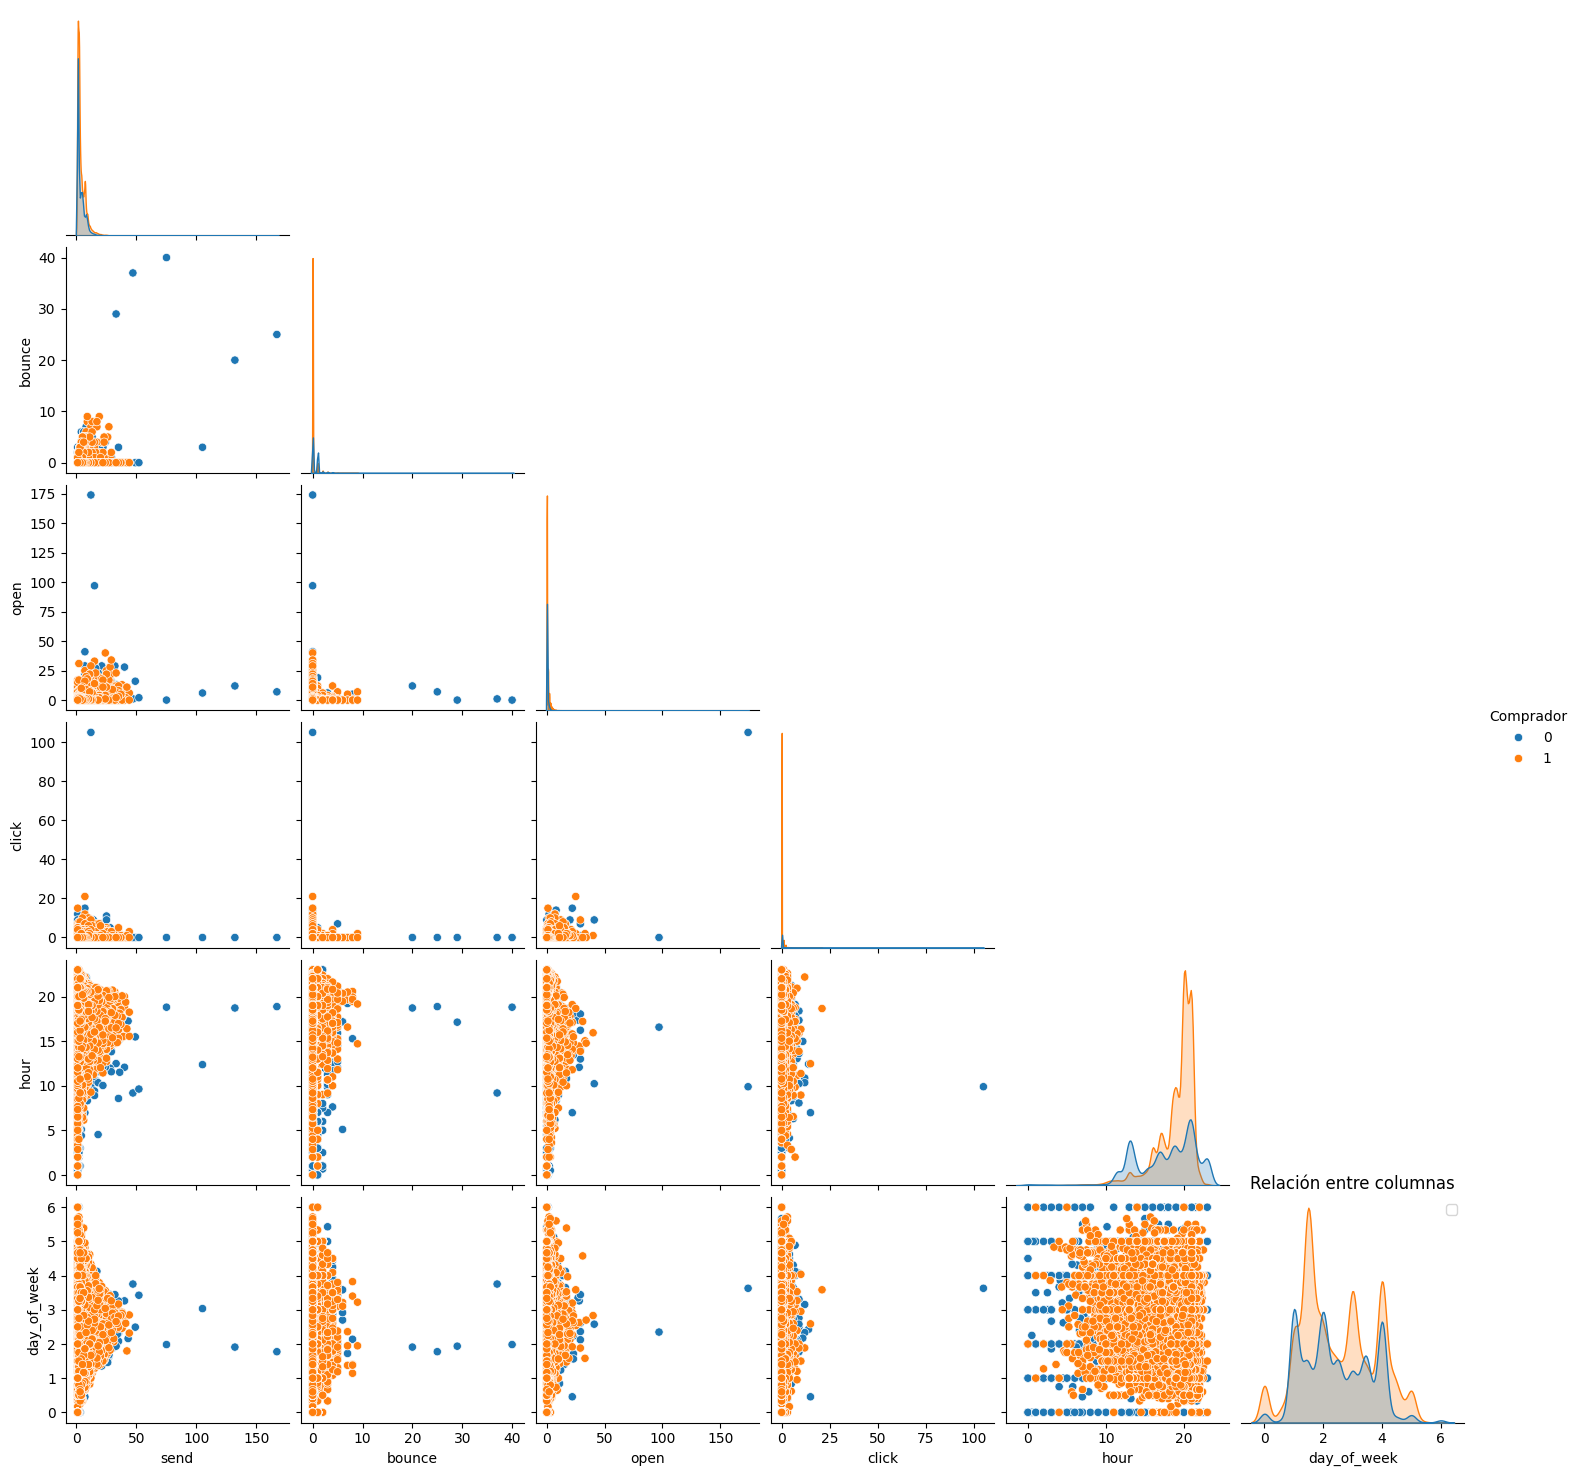

In [ ]:
plt.figure(figsize=(4, 4))
sns.pairplot(data=df_sampled.drop(columns='Id'), corner=True, diag_kind='kde', hue='Comprador')
plt.title('Relación entre columnas')
plt.legend()
plt.show()

#### Matriz de correlación

In [ ]:
# sns.heatmap()

TypeError: heatmap() missing 1 required positional argument: 'data'

#### Outliers

In [ ]:
columns_explore_outliers = ['send', 'bounce', 'open', 'click', 'hour','day_of_week']

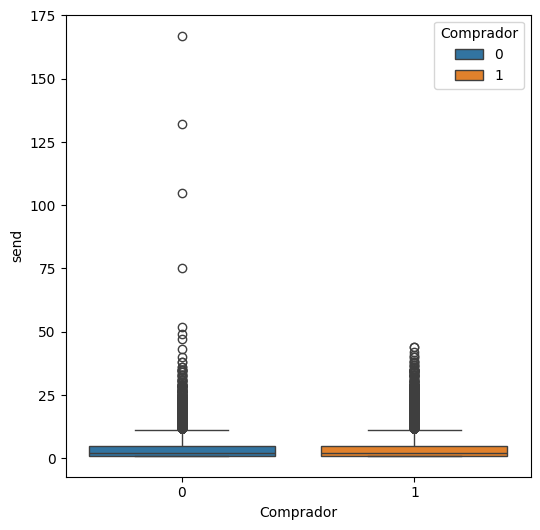

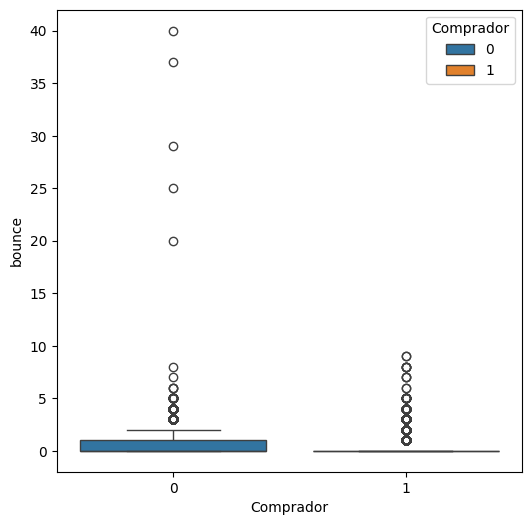

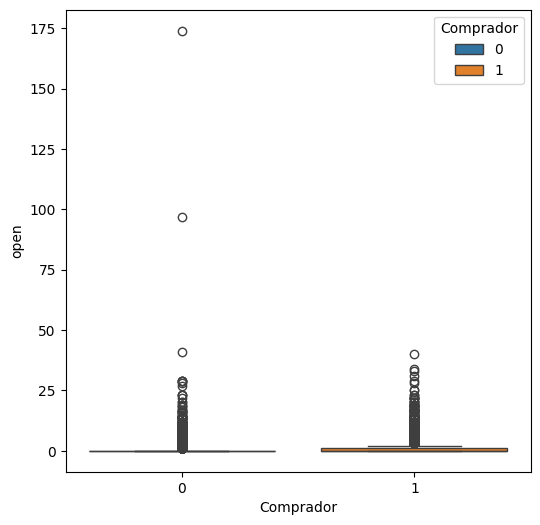

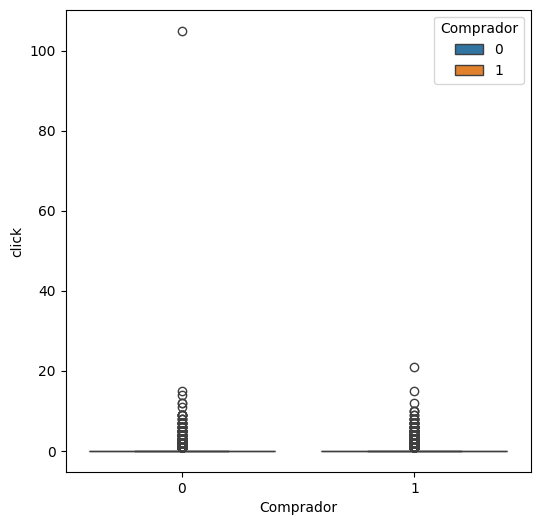

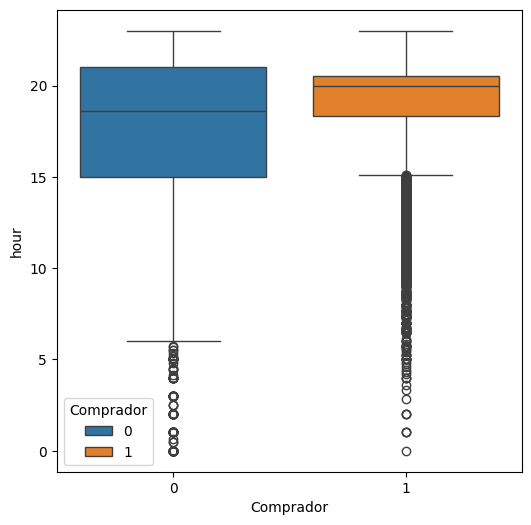

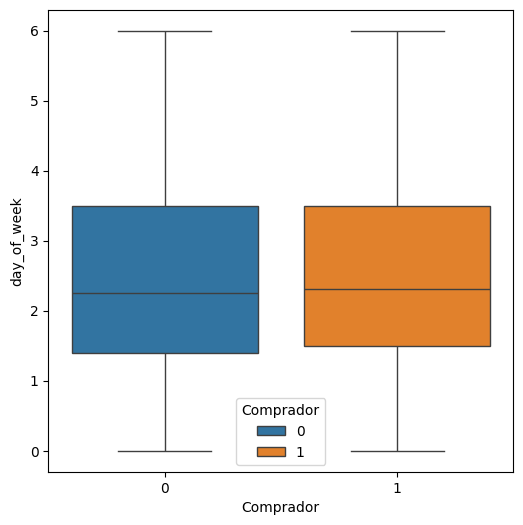

In [ ]:
for col in columns_explore_outliers:
  plt.figure(figsize=(6, 6))
  sns.boxplot(data=df_sampled, x='Comprador', y=col, hue='Comprador')
  plt.show()
  print()

### Preprocesamiento

#### Conversión de tipos de datos

In [ ]:
# dias y horas promedio a un solo decimal
df_sampled[['hour',	'day_of_week']] = df_sampled[['hour',	'day_of_week']].round(2)

#### Tratamiento de outliers

In [ ]:
# mask columna send
mask_outliers_send = df_sampled['send'] >= 75

# mask columna bounce
mask_outliers_bounce = df_sampled['bounce'] >= 20

# mask columna open
mask_outliers_open = df_sampled['open'] >= 75

# mask columna click
mask_outliers_click = df_sampled['click'] >= 40

In [ ]:
# filtrado de outliers
outliers_df = df_sampled[mask_outliers_send | mask_outliers_bounce | mask_outliers_open | mask_outliers_click]
df_sampled =  df_sampled[~(mask_outliers_send | mask_outliers_bounce | mask_outliers_open | mask_outliers_click)]

In [ ]:
outliers_df.shape

(8, 8)

In [ ]:
df_sampled.shape

(63680, 8)

#### Campos calculados

> Se evaluara el desempeńo de PCA, en caso de ser bajo, se crearan campos calculados manualmente.

In [ ]:
# -

#### Escalamiento
> En este caso como las variables estan en la misma escala (cm), no sera necesario escalarlas.

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler

StandardScaler a la columna `day_of_week`

In [ ]:
mm_scaler_dw = StandardScaler()
mm_scaler_dw.fit(X=X[['day_of_week']])
dw_scaled = mm_scaler_dw.transform(X[['day_of_week']])

In [ ]:
dw_scaled_S = pd.Series(data=dw_scaled.reshape(-1), name='day_of_week')

In [ ]:
dw_scaled_S.sample(3)

,day_of_week
53981,0.551142
32840,-0.796818
14065,-0.335977


RobustScaler al resto de columnas

In [ ]:
r_scaler_X = RobustScaler()
r_scaler_X.fit(X.drop(columns='day_of_week'))
X_scaled = r_scaler_X.transform(X.drop(columns='day_of_week'))

In [ ]:
X_scaled_df = pd.DataFrame(data=X_scaled, columns=X.drop(columns='day_of_week').columns)

In [ ]:
X_scaled_df.sample(3)

,Id,send,bounce,open,click,hour
2562,0.483162,1.00,0.0,0.0,0.0,-0.890909
26466,0.281525,0.00,0.0,0.0,0.0,-0.300000
24548,-0.667739,0.75,0.0,0.0,0.0,0.163636


Concatenando resultados dentro de un dataframe procesado

In [ ]:
X_scaled_df = pd.concat([X_scaled_df, dw_scaled_S], axis=1)

In [ ]:
X_scaled_df.shape

(63688, 7)

#### Reducción de dimensionalidad

In [ ]:
from sklearn.decomposition import PCA

**2 componentes**

In [ ]:
pca_2c = PCA(n_components=2)

In [ ]:
pca_2c.fit(X_scaled_df)

PCA(n_components=2)

In [ ]:
X_reduced = pca_2c.transform(X_scaled_df)

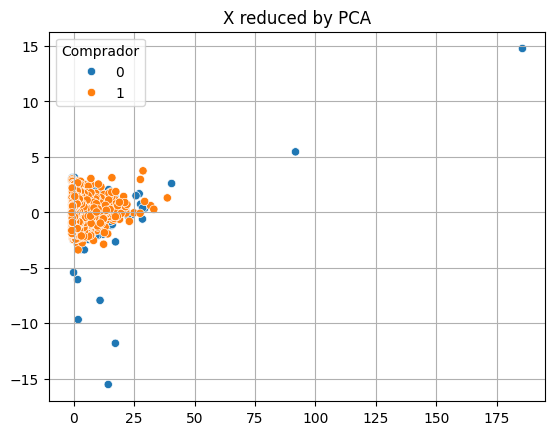

In [ ]:
sns.scatterplot(x=X_reduced[:,0], y=X_reduced[:,1], hue=y)
plt.title('X reduced by PCA')
plt.grid()
plt.show()

In [ ]:
pca_2c.n_components_

2

In [ ]:
pca_2c.explained_variance_

array([2.95204514, 1.04692067])

In [ ]:
pca_2c.explained_variance_ratio_

array([0.45117177, 0.16000469])

In [ ]:
np.sum(pca_2c.explained_variance_ratio_)

np.float64(0.6111764579675443)

Reducción sin PCA, por medio de feature engeniering manual:

> Se comparara la reducción de dimensionalidad entre PCA y la manual.

In [ ]:
''' data['area_sepalo'] = data['sepal length (cm)'] * data['sepal width (cm)'] '''

In [ ]:
''' data['area_petalo'] = data['petal length (cm)'] * data['petal width (cm)'] '''

In [ ]:
''' sns.scatterplot(x=data['area_petalo'], y=data['area_sepalo'], hue=y)
plt.title('Area petalo vs area sepalo')
plt.grid()
plt.show() '''

**3 componentes**

In [ ]:
pca_3c = PCA(n_components=3)

In [ ]:
pca_3c.fit(X)

PCA(n_components=3)

In [ ]:
X_reduced_3_c = pca_3c.transform(X)

In [ ]:
pca_3c.n_components_

3

In [ ]:
pca_3c.explained_variance_

array([3.74948319e+11, 1.53161520e+01, 9.48937999e+00])

In [ ]:
pca_3c.explained_variance_ratio_

array([1.00000000e+00, 4.08487017e-11, 2.53085012e-11])

In [ ]:
np.sum(pca_3c.explained_variance_ratio_)

np.float64(0.9999999999881135)

In [ ]:
import plotly.express as px

plotly scatter_3d: https://plotly.com/python-api-reference/generated/plotly.express.scatter_3d.html#plotly.express.scatter_3d

>[Ejemplo con dataset IRIS](https://plotly.com/python/3d-scatter-plots/)

In [ ]:
fig = px.scatter_3d(
    data_frame = X_reduced_3_c,
    x=X_reduced_3_c[:, 0],
    y=X_reduced_3_c[:, 1],
    z=X_reduced_3_c[:, 2],
    labels={'x' : 'Componente 1',
            'y' : 'Componente 2',
            'z' : 'Componente 3'})

fig.show()

Podemos obvservar que cuando al plotear los datos luego de PCA, las formas tienden a ser esfericas o con densidades variables, es mas optimo aplicar K-means, mienstras que si vemos otro tipos de formas mas convexas, lineales, entonces nos puede ser mas util DBSCAN.

> ![dbscan vs kmeans](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*KqWII7sFp1JL0EXwJGpqFw.png)

---

### Clustering con DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

#### Instancia y entrenamiento

Crearemos una lista de posibles clusters entre 2 y 5 (aunque ya sabemos que son 3 flores), con el fin de evaluar como se comporta DBSCAN en conjunto con el indice de silueta.

In [ ]:
from sklearn.metrics import silhouette_score
from tqdm import tqdm

In [ ]:
# Rango de hiperparámetros
rango_eps = np.arange(0.1, 5.0, 0.5)
rango_min_samples = np.arange(2, 4)

# Lista para almacenar resultados
resultados = []

# Búsqueda de hiperparámetros con barra de progreso
for min_sample in tqdm(rango_min_samples, desc='Buscando mejor combinación de hiperparámetros..'):
  for eps in rango_eps:
    dbscan_model = DBSCAN(min_samples=min_sample, eps=eps)
    dbscan_model.fit(X_reduced_3_c)
    clusters = dbscan_model.labels_
    if len([cluster for cluster in clusters if cluster != -1]) >= 2:
      silueta_score = silhouette_score(X=X_reduced_3_c, labels=clusters)
      resultados.append([min_sample, eps, silueta_score])

# Crear DataFrame de resultados
df_results = pd.DataFrame(data=resultados, columns=['min_samples', 'eps', 'silhouette_scores'])

# Obtener la mejor combinación
indice_mejor_combinacion = df_results['silhouette_scores'].idxmax()
best_silhouette_score = df_results.loc[indice_mejor_combinacion, 'silhouette_scores']

Buscando mejor combinación de hiperparámetros..: 100%|██████████| 2/2 [13:26<00:00, 403.42s/it]


#### Evaluación

In [ ]:
pivot = df_results.pivot(index='eps', columns='min_samples', values='silhouette_scores')
pivot.sample(3)

min_samples,2,3
eps,,
2.6,-0.939016,-0.920552
4.1,-0.847915,-0.973854
3.6,-0.881101,-0.973392


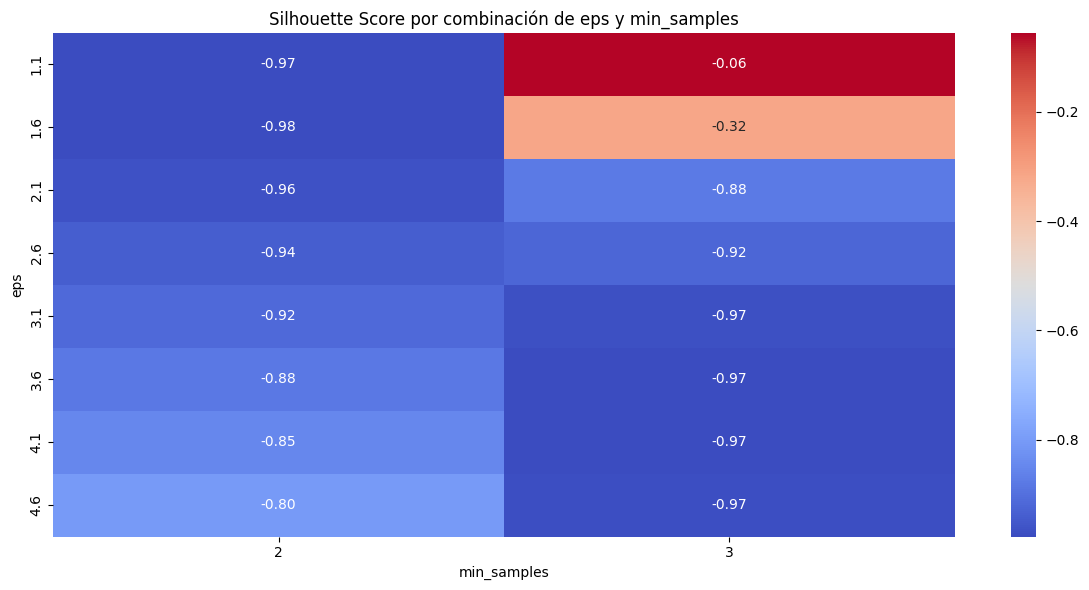

In [ ]:
# Visualización: Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Silhouette Score por combinación de eps y min_samples")
plt.tight_layout()
plt.show()

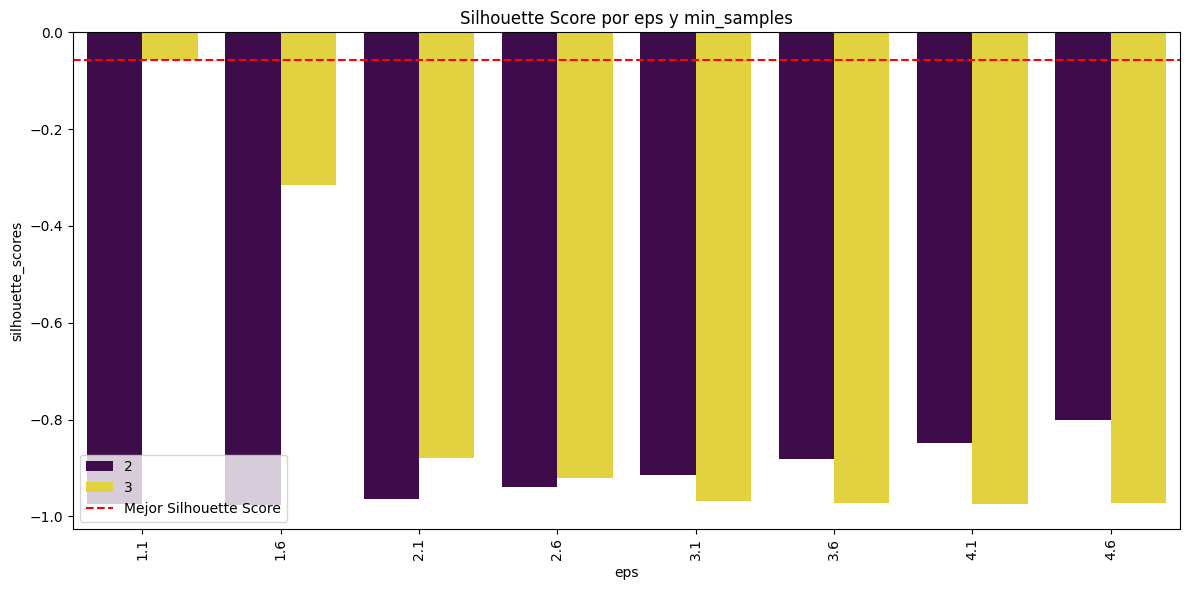

In [ ]:
# Visualización: Barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='eps', y='silhouette_scores', hue='min_samples', palette='viridis')
plt.axhline(best_silhouette_score, color='red', linestyle='--', label='Mejor Silhouette Score')
plt.title("Silhouette Score por eps y min_samples")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

La silueta nos muestra que a partir de 3 ejemplos minimos y un epsilon de 0.75, la relación entre coehesion y separación deja de mejorar.

### Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Una vez que ya sabemos los valores optimos para cada etapa, los podemos orquestar dentro de un pipeline:



In [ ]:
X_scaler = ColumnTransformer(
    [
        ('days_sc', StandardScaler(), ['day_of_week']),
        ('X_rs', RobustScaler(), X.drop(columns='day_of_week').columns)
    ],
    remainder='passthrough'
)

In [ ]:
dbscan_pipe = Pipeline(
    steps=[
        ('X_scaler', X_scaler),
        ('pca_3c', PCA(n_components=3)),
        ('dbscan', DBSCAN(eps=1.1, min_samples=3)),
    ]
)

NameError: name 'DBSCAN' is not defined

In [ ]:
dbscan_pipe.fit(X)

Pipeline(steps=[('X_scaler',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('days_sc', StandardScaler(),
                                                  ['day_of_week']),
                                                 ('X_rs', RobustScaler(),
                                                  Index(['Id', 'send', 'bounce', 'open', 'click', 'hour'], dtype='object'))])),
                ('pca_3c', PCA(n_components=3)),
                ('dbscan', DBSCAN(eps=1.1, min_samples=3))])

In [ ]:
dbscan_pipe.named_steps

{'X_scaler': ColumnTransformer(remainder='passthrough',
                   transformers=[('days_sc', StandardScaler(), ['day_of_week']),
                                 ('X_rs', RobustScaler(),
                                  Index(['Id', 'send', 'bounce', 'open', 'click', 'hour'], dtype='object'))]),
 'pca_3c': PCA(n_components=3),
 'dbscan': DBSCAN(eps=1.1, min_samples=3)}

In [ ]:
y_clusters = dbscan_pipe['dbscan'].labels_

In [ ]:
y_clusters

array([0, 0, 0, ..., 0, 0, 0])

Explicabilidad de caracteristicas importantes:

Dado que que el conjunto de datos es pequeńo y utilizaremos `RandomForestClassifier` con los parámetros por defecto, para poder encontrar las caracteristicas mas importantes.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_classifier = RandomForestClassifier()

Le pasamos el dataset original sin la columna target, para asi poder entrenar el modelo con los nombres reales de las columnas y poder obtener la importancia en base a su nombre.

In [ ]:
rf_classifier.fit(X = X, y = y_clusters)

RandomForestClassifier()

In [ ]:
importancia_caracteristicas = rf_classifier.feature_importances_

In [ ]:
caracteristicas = X.columns

In [ ]:
caracteristicas_segun_importancia = pd.DataFrame({
    'caracteristica': caracteristicas,
    'importancia': importancia_caracteristicas
})

In [ ]:
caracteristicas_segun_importancia = caracteristicas_segun_importancia.sort_values(by='importancia', ascending=False).reset_index(drop=True)

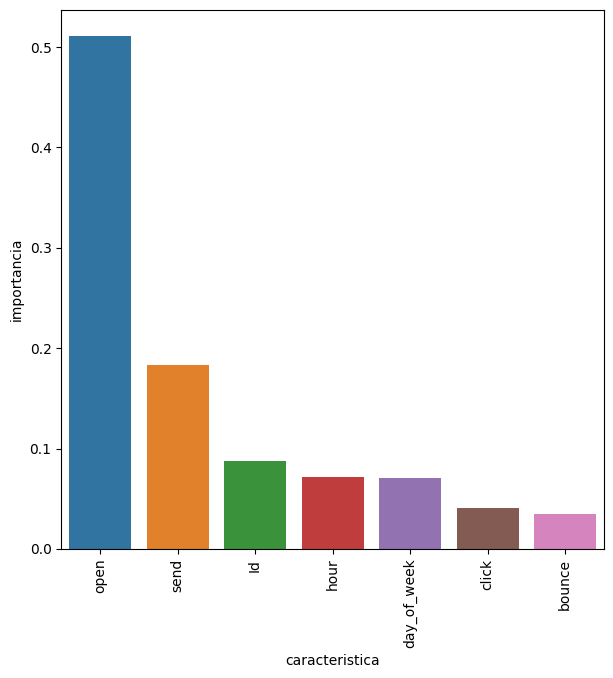

In [ ]:
plt.figure(figsize=(7, 7))
sns.barplot(data=caracteristicas_segun_importancia, x='caracteristica', y='importancia', hue='caracteristica')
plt.xticks(rotation=90)
plt.show()

---

### Clustering con k-means

In [ ]:
from sklearn.cluster import KMeans

#### Instancia y entrenamiento

Crearemos una lista de posibles clusters entre 2 y 5, con el fin de evaluar como se comporta kmeans en conjunto con el indice de silueta.

In [ ]:
from sklearn.metrics import silhouette_score
from tqdm import tqdm
import numpy as np

In [ ]:
# Rango de hiperparámetros
rango_clusters = np.arange(2, 6, 1)

# Lista para almacenar resultados
resultados = []

# Búsqueda de hiperparámetros con barra de progreso
for cluster in tqdm(rango_clusters, desc='Buscando mejor combinación de hiperparámetros..'):
  kmeans_model = KMeans(n_clusters=cluster)
  kmeans_model.fit(X_reduced_3_c)
  clusters = kmeans_model.labels_
  silueta_score = silhouette_score(X=X_reduced_3_c, labels=clusters)
  resultados.append([cluster, kmeans_model.inertia_, silueta_score])

Buscando mejor combinación de hiperparámetros..: 100%|██████████| 4/4 [02:55<00:00, 43.91s/it]


NameError: name 'indice_mejor_combinacion' is not defined

In [ ]:
# Crear DataFrame de resultados
df_results = pd.DataFrame(data=resultados, columns=['clusters', 'inertia_score', 'silhouette_scores'])

# Obtener la mejor combinación
indice_mejor_combinacion_silueta = df_results['silhouette_scores'].idxmax()
indice_mejor_combinacion_inertia = df_results['inertia_score'].idxmax()
mejor_silhouette_score = df_results.loc[indice_mejor_combinacion_silueta, 'silhouette_scores']
mejor_inertia_score = df_results.loc[indice_mejor_combinacion_inertia, 'inertia_score']

In [ ]:
df_melted = df_results.melt(id_vars='clusters',
                            value_vars=['silhouette_scores', 'inertia_score'],
                            var_name='métrica', value_name='valor')

In [ ]:
df_melted

,clusters,métrica,valor
0,2,silhouette_scores,6.259931e-01
1,3,silhouette_scores,5.920351e-01
2,4,silhouette_scores,5.726839e-01
3,5,silhouette_scores,5.607637e-01
4,2,inertia_score,5.983699e+15
5,3,inertia_score,2.639018e+15
6,4,inertia_score,1.489471e+15
7,5,inertia_score,9.580635e+14


In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
df_melted_scaled = pd.DataFrame()

In [ ]:
metricas_rs = RobustScaler()
metricas_rs.fit(df_melted[['valor']])
df_melted_scaled[['valor']] = metricas_rs.transform(df_melted[['valor']])

In [ ]:
df_melted_scaled[['clusters', 'métrica']] = df_melted[['clusters', 'métrica']]

In [ ]:
df_melted_scaled

,clusters,métrica,valor
0,2,silhouette_scores,-0.269595
1,3,silhouette_scores,-0.269595
2,4,silhouette_scores,-0.269595
3,5,silhouette_scores,-0.269595
4,2,inertia_score,3.097978
5,3,inertia_score,1.215621
6,4,inertia_score,0.568666
7,5,inertia_score,0.269595


#### Evaluación

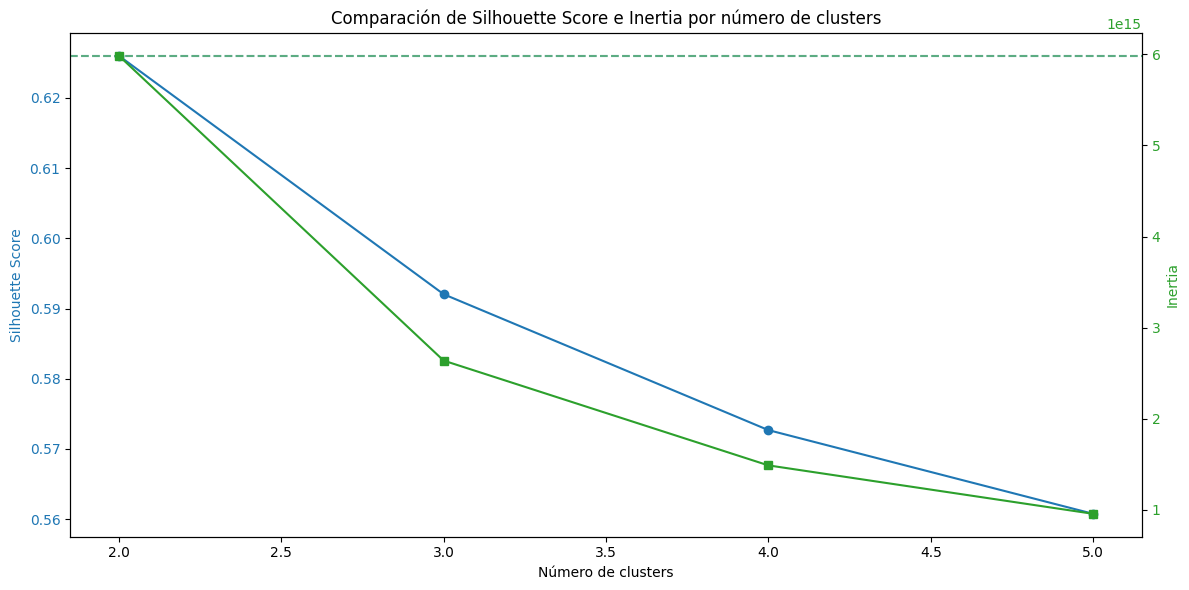

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primer eje Y (silhouette score)
color1 = 'tab:blue'
ax1.set_xlabel('Número de clusters')
ax1.set_ylabel('Silhouette Score', color=color1)
ax1.plot(df_results['clusters'], df_results['silhouette_scores'], marker='o', color=color1, label='Silhouette Score')
ax1.axhline(mejor_silhouette_score, color=color1, linestyle='--', alpha=0.5)
ax1.tick_params(axis='y', labelcolor=color1)

# Segundo eje Y (inertia)
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Inertia', color=color2)
ax2.plot(df_results['clusters'], df_results['inertia_score'], marker='s', color=color2, label='Inertia')
ax2.axhline(mejor_inertia_score, color=color2, linestyle='--', alpha=0.5)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Comparación de Silhouette Score e Inertia por número de clusters")
fig.tight_layout()
plt.show()

La silueta nos muestra que a partir de 3 ejemplos minimos y un epsilon de 0.75, la relación entre coehesion y separación deja de mejorar.

### Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Una vez que ya sabemos los valores optimos para cada etapa, los podemos orquestar dentro de un pipeline:



In [ ]:
kmeans_pipe = Pipeline(
    steps=[
        ('X_scaler', X_scaler),
        ('pca_3c', PCA(n_components=3)),
        ('KMeans', KMeans(n_clusters=2)),
    ]
)

In [ ]:
kmeans_pipe.fit(X)

Pipeline(steps=[('X_scaler',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('days_sc', StandardScaler(),
                                                  ['day_of_week']),
                                                 ('X_rs', RobustScaler(),
                                                  Index(['Id', 'send', 'bounce', 'open', 'click', 'hour'], dtype='object'))])),
                ('pca_3c', PCA(n_components=3)),
                ('KMeans', KMeans(n_clusters=2))])

In [ ]:
kmeans_pipe.named_steps

{'X_scaler': ColumnTransformer(remainder='passthrough',
                   transformers=[('days_sc', StandardScaler(), ['day_of_week']),
                                 ('X_rs', RobustScaler(),
                                  Index(['Id', 'send', 'bounce', 'open', 'click', 'hour'], dtype='object'))]),
 'pca_3c': PCA(n_components=3),
 'KMeans': KMeans(n_clusters=2)}

In [ ]:
y_clusters = kmeans_pipe['KMeans'].labels_

In [ ]:
y_clusters

array([0, 1, 1, ..., 0, 1, 1], dtype=int32)

Explicabilidad de caracteristicas importantes:

Dado que que el conjunto de datos es pequeńo y utilizaremos `RandomForestClassifier` con los parámetros por defecto, para poder encontrar las caracteristicas mas importantes.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_classifier = RandomForestClassifier()

Le pasamos el dataset original sin la columna target, para asi poder entrenar el modelo con los nombres reales de las columnas y poder obtener la importancia en base a su nombre.

In [ ]:
rf_classifier.fit(X = X, y = y_clusters)

RandomForestClassifier()

In [ ]:
importancia_caracteristicas = rf_classifier.feature_importances_

In [ ]:
caracteristicas = X.columns

In [ ]:
caracteristicas_segun_importancia = pd.DataFrame({
    'caracteristica': caracteristicas,
    'importancia': importancia_caracteristicas
})

In [ ]:
caracteristicas_segun_importancia = caracteristicas_segun_importancia.sort_values(by='importancia', ascending=False).reset_index(drop=True)

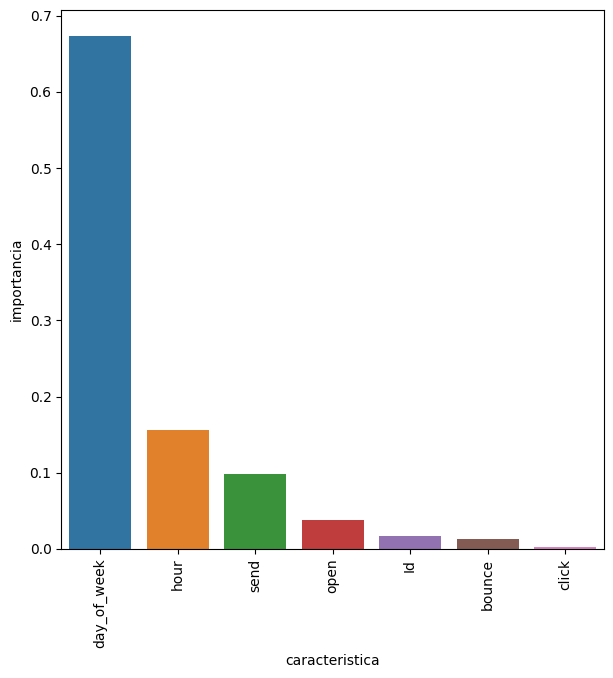

In [ ]:
plt.figure(figsize=(7, 7))
sns.barplot(data=caracteristicas_segun_importancia, x='caracteristica', y='importancia', hue='caracteristica')
plt.xticks(rotation=90)
plt.show()